In [1]:
from telescope import *
from spectrograph import *
from detector import *
from spectralmodels import Sky, get_list_of_stellar_models, get_stellar_spectrum
from etc.etc import simulate_1D_spectrum, simulate_2D_spectrum, SpecETC

from pathlib import Path
from astropy.table import Table
import numpy as np
from matplotlib import pyplot as plt

In [2]:
models = get_list_of_stellar_models(verbose=True)
sptype = 'M5V'
mag = 12
star = get_stellar_spectrum(sptype=sptype, mag=mag)
sky = Sky(seeing=3.0*u.arcsec, mag=18)

O ['O9V', 'O5V', 'O8III']
B ['B9III', 'B3V', 'B5III', 'B8V', 'B5I', 'B0I', 'B1-2III', 'B2II', 'B0V', 'B6IV', 'B1V', 'B5-7V', 'B5II', 'B8I', 'B2IV']
A ['A0V', 'A0I', 'A5V', 'A5III', 'A0IV', 'A0III', 'A4-7IV', 'A3V', 'A2V']
F ['F5I', 'F5IV', 'F0II', 'F0I', 'F0III', 'F2V', 'F8V', 'F0V', 'F5V', 'F2II', 'F8IV', 'F8I', 'F0-2IV', 'F5III']
G ['G5II', 'G0V', 'G2IV', 'G5IV', 'G2V', 'G8I', 'G8IV', 'G0III', 'G5V', 'G0IV', 'G5I', 'G8V', 'G8III', 'G0I', 'G5III']
K ['K5III', 'K3-4II', 'K4I', 'K0IV', 'K3III', 'K0III', 'K7V', 'K2I', 'K5V', 'K3IV', 'K1IV', 'K0-1II', 'K2V', 'K0V']
M ['M10III', 'M5V', 'M0III', 'M5III', 'M2I', 'M3II', 'M0V', 'M4V', 'M2V']


(432, 5496)


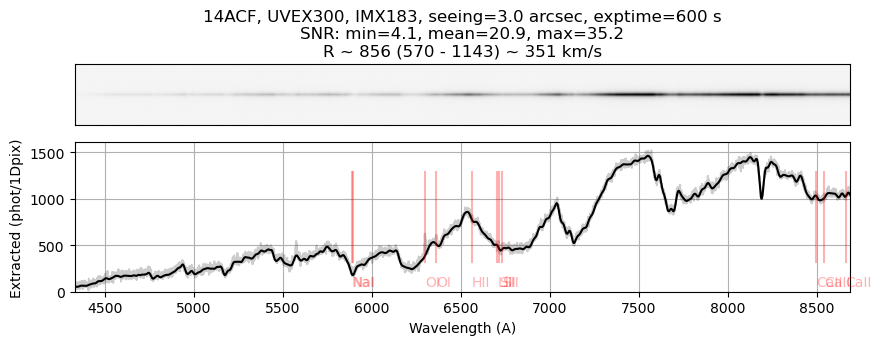

In [3]:
IMX183.exptime = 600*u.second
im, spec, var = SpecETC(star, sky, ACF14, UVEX300, IMX183, plot=True)

(432, 5496)


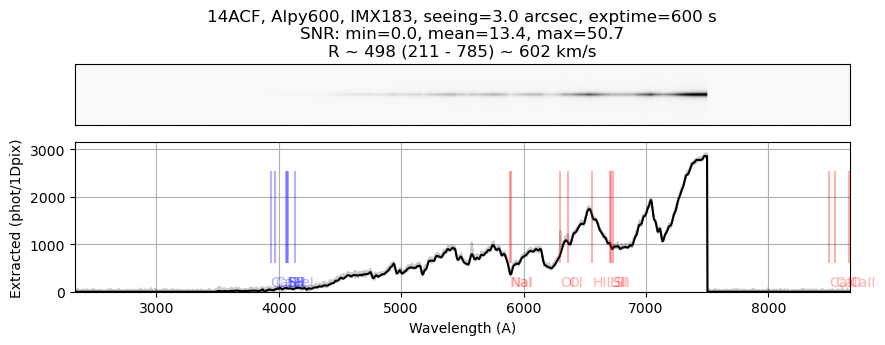

In [4]:
im, spec, var = SpecETC(star, sky, ACF14, Alpy600, IMX183, plot=True)

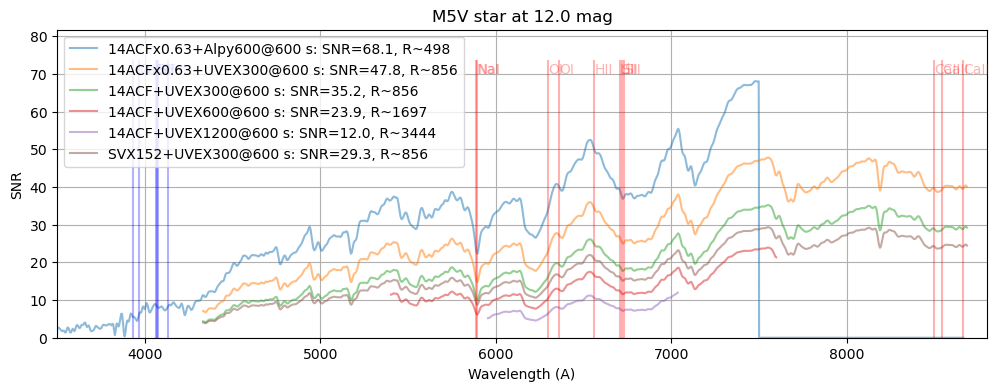

In [5]:
instrumentation = [
                   (ACF14reduced, Alpy600, IMX183, 600*u.second),
                   (ACF14reduced, UVEX300, IMX183, 600*u.second),
                   (ACF14, UVEX300, IMX183, 600*u.second),
                   (ACF14, UVEX600, IMX183, 600*u.second),
                   (ACF14, UVEX1200, IMX183, 600*u.second),
                   (SVX152, UVEX300, IMX183, 600*u.second),
                  ]

plt.figure(figsize=(12,4))
plt.title(f'{sptype} star at {mag:.1f} mag')
peakSNR = 0
wavmin = 3500
wavmax = 8800
for inst in instrumentation:
    tel, spec, det, exptime = inst
    det.exptime = exptime
    spec.set_detector(det)
    im, spectra, variance = SpecETC(star, sky, tel, spec, det, plot=False)
    R = np.mean(spec.R)

    SNR = spectra/variance**0.5
    label = f"{tel.name}+{spec.name}@{det.exptime:.0f}: SNR={max(SNR):.1f}, R~{R:.0f}"
    plt.plot(spec.binset, SNR, alpha=0.5, label=label)
    peakSNR = peakSNR if max(SNR) <= peakSNR else max(SNR)

lines_file = Path('.') / 'data' / 'spectral_lines.csv'
lines = Table.read(lines_file, format='ascii.csv')
for line in lines:
    if line['wav'] > wavmin and line['wav'] < wavmax:
        color = 'b' if line['wav'] < 5500 else 'r'
        alpha = 0.3
        plt.axvline(line['wav'], ymin=0, ymax=0.9,
                    color=color, alpha=alpha)
        plt.text(line['wav'], 1.03*peakSNR, line['name'],
                 color=color, alpha=alpha)

plt.ylabel('SNR')
plt.xlabel('Wavelength (A)')
plt.xlim(wavmin, wavmax)
plt.ylim(0,1.2*peakSNR)
plt.grid()
plt.legend(loc='best')
plt.show()